In [1]:
pip install pytrends


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
# -*- coding: utf-8 -*-
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
import time
import sys

# ---------- 사용자 입력 ----------
kw1 = input("키워드 1 (예: 여행): ").strip()
kw2 = input("키워드 2 (예: 여행 코디): ").strip()
tf_in = input("timeframe (엔터=최근 2년, 예: 'today 2-y' 또는 '2023-09-22 2025-09-22'): ").strip()
geo_in = input("지역코드(예: KR, US, 공란=전세계): ").strip().upper()

if not kw1 or not kw2:
    print("키워드가 비었습니다. 종료합니다.")
    sys.exit(1)

timeframe = tf_in if tf_in else "today 2-y"
geo = geo_in if geo_in else ""

kw_list = [kw1, kw2]

# ---------- pytrends 세션 ----------
# timeout은 여기에서만 지정! requests_args에는 timeout 넣지 마세요.
pytrends = TrendReq(
    hl='ko-KR',
    tz=540,
    timeout=(5, 20),       # (connect, read)
    retries=2,
    backoff_factor=0.5,
    requests_args={}       # timeout 금지
)

# ---------- 요청 전 대기 ----------
time.sleep(1.0)

# ---------- 데이터 요청 ----------
pytrends.build_payload(
    kw_list=kw_list,
    cat=0,
    timeframe=timeframe,
    geo=geo,
    gprop=''  # 웹 검색
)

df = pytrends.interest_over_time()
if df.empty:
    raise ValueError("빈 데이터가 반환되었습니다. 키워드/기간/지역을 바꿔 다시 시도하세요.")

if 'isPartial' in df.columns:
    df = df.drop(columns=['isPartial'])

# ---------- 상관계수 ----------
corr = df[kw_list].corr(method='pearson')
print("\n검색어별 상관계수(피어슨):")
print(corr)

# ---------- 저장 ----------
out_csv = f"trends_{kw1}_{kw2}.csv".replace(" ", "_")
df.to_csv(out_csv, encoding="utf-8-sig")
print(f"\nCSV 저장 완료 → {out_csv}")

# ---------- 시각화 ----------
# (가능하면 나눔고딕 폰트, 없으면 기본)
try:
    plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

# 원시 시계열
ax = df[kw_list].plot(figsize=(11, 5), linewidth=1.2,
                      title=f"Google Trends: {kw1} vs {kw2} ({timeframe}, geo={geo or 'WORLD'})")
ax.set_xlabel("날짜")
ax.set_ylabel("관심도 (0~100)")
ax.legend(kw_list)
plt.tight_layout()
plt.show()

# 4주 이동평균
ma_window = 4
df_ma = df[kw_list].rolling(window=ma_window, min_periods=1).mean()
ax2 = df_ma.plot(figsize=(11, 5), linewidth=2.0,
                 title=f"이동평균({ma_window}주) — 상관계수: {corr.iloc[0,1]:.3f}")
ax2.set_xlabel("날짜")
ax2.set_ylabel("관심도 (0~100)")
ax2.legend([f"{kw1}(MA{ma_window})", f"{kw2}(MA{ma_window})"])
plt.tight_layout()
plt.show()


키워드 1 (예: 여행):  여행
키워드 2 (예: 여행 코디):  코디
timeframe (엔터=최근 2년, 예: 'today 2-y' 또는 '2023-09-22 2025-09-22'):  최근 2년
지역코드(예: KR, US, 공란=전세계):  KR


TypeError: Retry.__init__() got an unexpected keyword argument 'method_whitelist'

In [18]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False


C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\user\AppData\Local\Temp\ipykernel_924\1105110092.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  "날짜": pd.to_datetime(df_raw["연령대"], errors="coerce"),


상관계수 표 (피어슨):
            여행       여행룩      공항패션      리조트룩      여행코디
여행    1.000000  0.694127  0.099235  0.418294  0.031525
여행룩   0.694127  1.000000  0.202750  0.760909  0.070281
공항패션  0.099235  0.202750  1.000000  0.122589  0.016916
리조트룩  0.418294  0.760909  0.122589  1.000000  0.067083
여행코디  0.031525  0.070281  0.016916  0.067083  1.000000


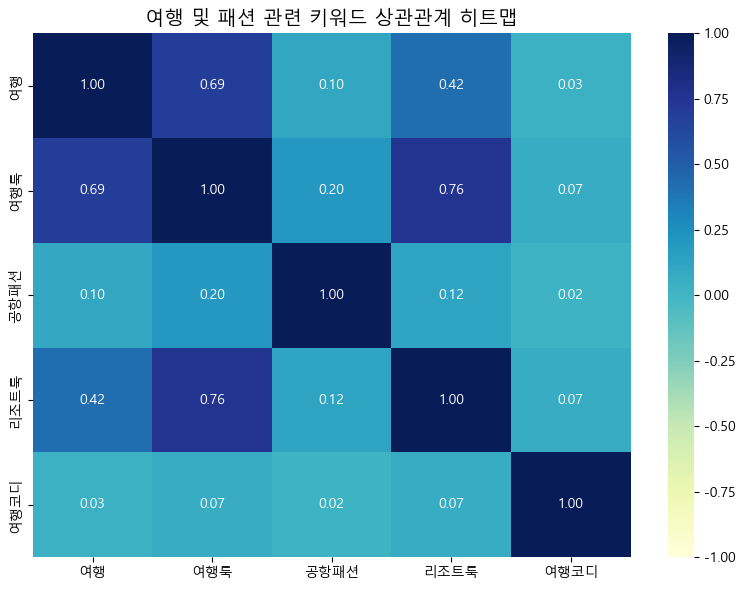

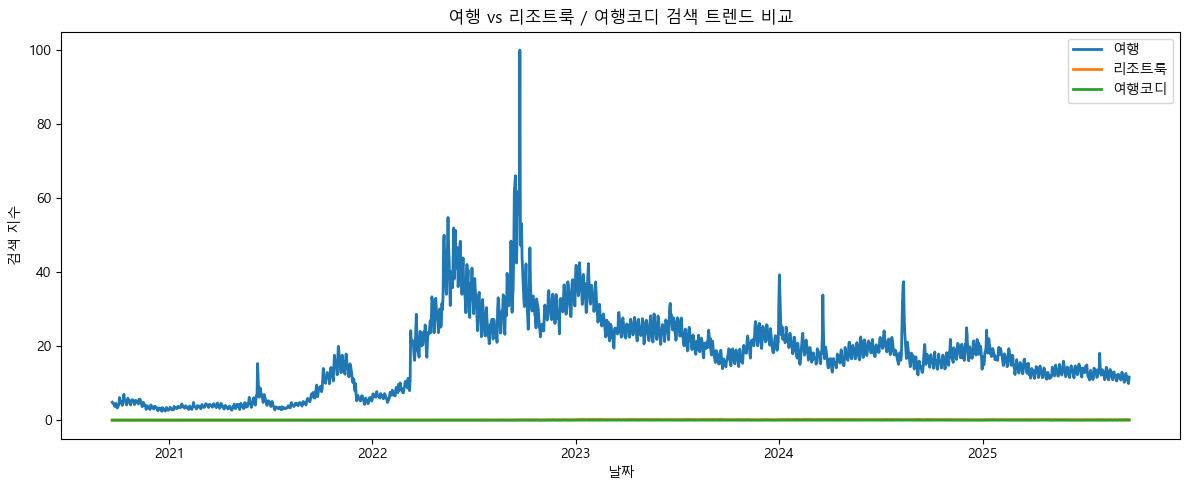

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm




# 1) 데이터 불러오기 (루트 폴더에 datalab.xlsx가 있어야 함)
file_path = "datalab (1).xlsx"
df_raw = pd.read_excel(file_path, sheet_name="개요", header=5)

# 2) 전처리
df = pd.DataFrame({
    "날짜": pd.to_datetime(df_raw["연령대"], errors="coerce"),
    "여행": pd.to_numeric(df_raw["전체"], errors="coerce"),
    "여행룩": pd.to_numeric(df_raw["Unnamed: 3"], errors="coerce"),
    "공항패션": pd.to_numeric(df_raw["Unnamed: 5"], errors="coerce"),
    "리조트룩": pd.to_numeric(df_raw["Unnamed: 7"], errors="coerce"),
    "여행코디": pd.to_numeric(df_raw["Unnamed: 9"], errors="coerce")
})
df = df.dropna()

# 3) 상관계수 계산
corr = df.drop(columns=["날짜"]).corr(method="pearson")
print("상관계수 표 (피어슨):")
print(corr)

# 4) 상관계수 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", vmin=-1, vmax=1)
plt.title("여행 및 패션 관련 키워드 상관관계 히트맵", fontsize=14)
plt.tight_layout()
plt.show()

# 5) 시계열 그래프 (여행 vs 리조트룩, 여행 vs 여행코디)
plt.figure(figsize=(12, 5))
plt.plot(df["날짜"], df["여행"], label="여행", linewidth=2)
plt.plot(df["날짜"], df["리조트룩"], label="리조트룩", linewidth=2)
plt.plot(df["날짜"], df["여행코디"], label="여행코디", linewidth=2)
plt.legend()
plt.xlabel("날짜")
plt.ylabel("검색 지수")
plt.title("여행 vs 리조트룩 / 여행코디 검색 트렌드 비교")
plt.tight_layout()
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\user\AppData\Local\Temp\ipykernel_924\62067556.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  "날짜": pd.to_datetime(df_raw["연령대"], errors="coerce"),


상관계수 표 (피어슨):
            여행       여행룩      공항패션      리조트룩      여행코디
여행    1.000000  0.502198  0.456762  0.647488  0.582076
여행룩   0.502198  1.000000  0.702946  0.602829  0.638440
공항패션  0.456762  0.702946  1.000000  0.526111  0.497251
리조트룩  0.647488  0.602829  0.526111  1.000000  0.471519
여행코디  0.582076  0.638440  0.497251  0.471519  1.000000


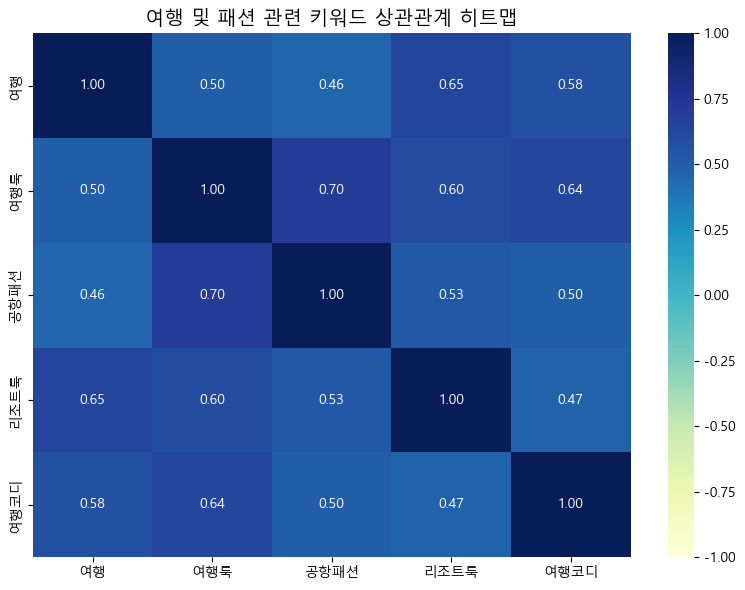

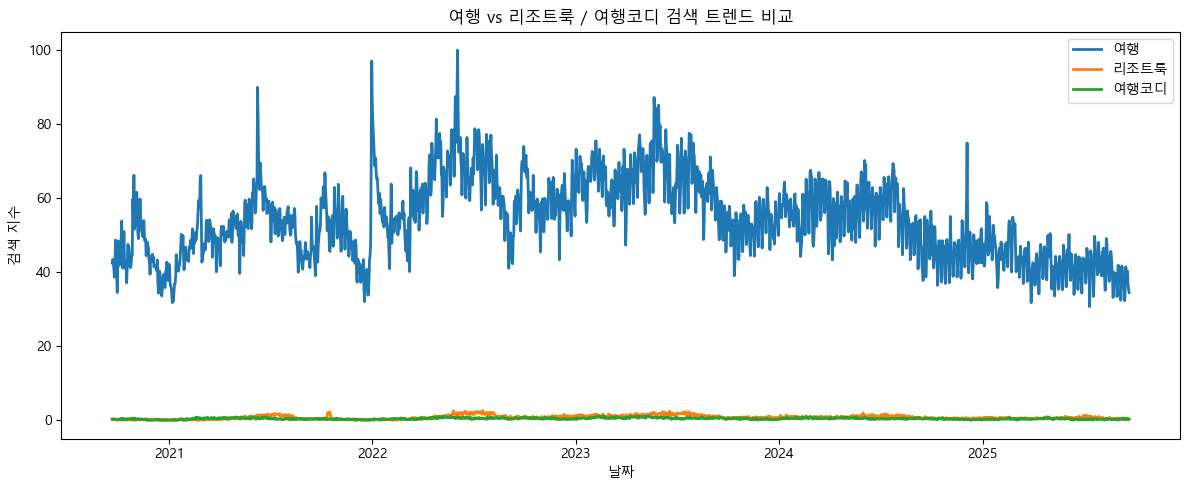

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm




# 1) 데이터 불러오기 (루트 폴더에 datalab.xlsx가 있어야 함)
file_path = "datalab.xlsx"
df_raw = pd.read_excel(file_path, sheet_name="개요", header=5)

# 2) 전처리
df = pd.DataFrame({
    "날짜": pd.to_datetime(df_raw["연령대"], errors="coerce"),
    "여행": pd.to_numeric(df_raw["전체"], errors="coerce"),
    "여행룩": pd.to_numeric(df_raw["Unnamed: 3"], errors="coerce"),
    "공항패션": pd.to_numeric(df_raw["Unnamed: 5"], errors="coerce"),
    "리조트룩": pd.to_numeric(df_raw["Unnamed: 7"], errors="coerce"),
    "여행코디": pd.to_numeric(df_raw["Unnamed: 9"], errors="coerce")
})
df = df.dropna()

# 3) 상관계수 계산
corr = df.drop(columns=["날짜"]).corr(method="pearson")
print("상관계수 표 (피어슨):")
print(corr)

# 4) 상관계수 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", vmin=-1, vmax=1)
plt.title("여행 및 패션 관련 키워드 상관관계 히트맵", fontsize=14)
plt.tight_layout()
plt.show()

# 5) 시계열 그래프 (여행 vs 리조트룩, 여행 vs 여행코디)
plt.figure(figsize=(12, 5))
plt.plot(df["날짜"], df["여행"], label="여행", linewidth=2)
plt.plot(df["날짜"], df["리조트룩"], label="리조트룩", linewidth=2)
plt.plot(df["날짜"], df["여행코디"], label="여행코디", linewidth=2)
plt.legend()
plt.xlabel("날짜")
plt.ylabel("검색 지수")
plt.title("여행 vs 리조트룩 / 여행코디 검색 트렌드 비교")
plt.tight_layout()
plt.show()


상관계수 표 (피어슨):
                   여행       여행룩   해외여행 코디  여행 인플루언서 코디
여행           1.000000  0.694127  0.418294     0.031525
여행룩          0.694127  1.000000  0.760909     0.070281
해외여행 코디      0.418294  0.760909  1.000000     0.067083
여행 인플루언서 코디  0.031525  0.070281  0.067083     1.000000


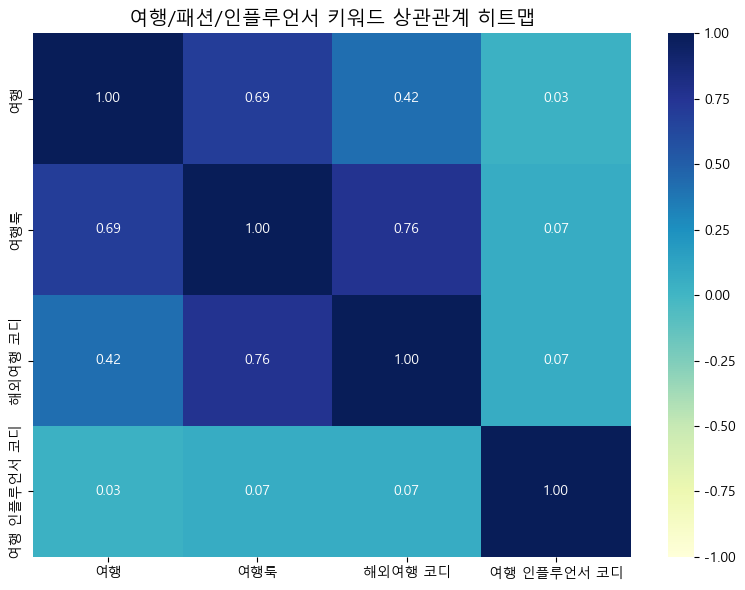

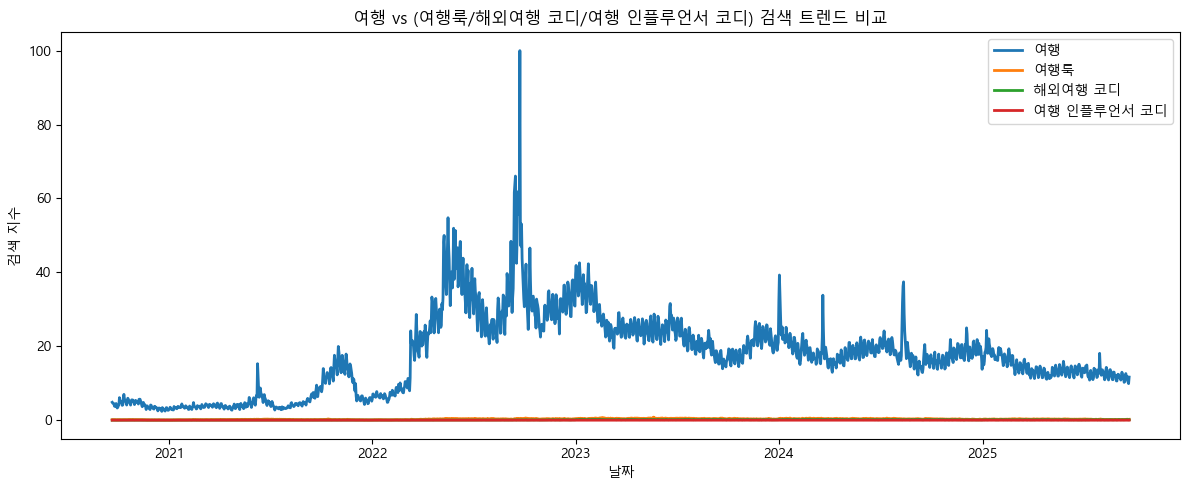

In [23]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# 1) 데이터 불러오기 (시트: 개요, header=5)
#    파일명은 로컬에 맞게 변경하세요.
# ------------------------------------------------
file_path = "datalab (1).xlsx"   # ← 본인 파일명/경로로 조정
sheet_name = "개요"

df_raw = pd.read_excel(file_path, sheet_name=sheet_name, header=5)

# df_raw 컬럼은 대략 아래와 같은 형태입니다.
# ['연령대','전체','Unnamed: 2','Unnamed: 3','Unnamed: 4','Unnamed: 5','Unnamed: 6','Unnamed: 7','Unnamed: 8','Unnamed: 9']
# 0열: 날짜(텍스트 '날짜'가 한 번 더 섞여 있어서 정리 필요)
# 1열: '여행' 값
# 3열: '여행룩' 값
# 5열: '날씨' 값
# 7열: '해외여행 코디' 값
# 9열: '여행 인플루언서 코디' 값

# ------------------------------------------------
# 2) 전처리: 필요한 열만 뽑아 이름을 한글 라벨로 정리
#    (반복되는 '날짜' 열은 버리고 값 열만 사용)
# ------------------------------------------------
df = pd.DataFrame({
    "날짜": pd.to_datetime(df_raw.iloc[:, 0], format="%Y-%m-%d", errors="coerce"),
    "여행": pd.to_numeric(df_raw.iloc[:, 1], errors="coerce"),
    "여행룩": pd.to_numeric(df_raw.iloc[:, 3], errors="coerce"),
    "날씨": pd.to_numeric(df_raw.iloc[:, 5], errors="coerce"),
    "해외여행 코디": pd.to_numeric(df_raw.iloc[:, 7], errors="coerce"),
    "여행 인플루언서 코디": pd.to_numeric(df_raw.iloc[:, 9], errors="coerce"),
})

# '날짜'가 파싱되지 않은 헤더성 행 제거 + 완전 결측 행 제거
df = df.dropna(subset=["날짜"]).dropna(how="all", subset=["여행","여행룩","날씨","해외여행 코디","여행 인플루언서 코디"])
df = df.sort_values("날짜").reset_index(drop=True)

# ------------------------------------------------
# 3) 상관계수 계산 (여행/여행룩/해외여행 코디/여행 인플루언서 코디 중심)
#    필요하면 '날씨'도 포함해보세요.
# ------------------------------------------------
corr_targets = ["여행", "여행룩", "해외여행 코디", "여행 인플루언서 코디"]  # '날씨'까지 포함하려면 리스트에 추가
corr = df[corr_targets].corr(method="pearson")
print("상관계수 표 (피어슨):")
print(corr)

# ------------------------------------------------
# 4) 상관계수 히트맵
# ------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", vmin=-1, vmax=1)
plt.title("여행/패션/인플루언서 키워드 상관관계 히트맵", fontsize=14)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 5) 시계열 그래프: 여행 vs (여행룩/해외여행 코디/여행 인플루언서 코디)
# ------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(df["날짜"], df["여행"], label="여행", linewidth=2)
plt.plot(df["날짜"], df["여행룩"], label="여행룩", linewidth=2)
plt.plot(df["날짜"], df["해외여행 코디"], label="해외여행 코디", linewidth=2)
plt.plot(df["날짜"], df["여행 인플루언서 코디"], label="여행 인플루언서 코디", linewidth=2)
plt.legend()
plt.xlabel("날짜")
plt.ylabel("검색 지수")
plt.title("여행 vs (여행룩/해외여행 코디/여행 인플루언서 코디) 검색 트렌드 비교")
plt.tight_layout()
plt.show()

# (선택) CSV로 저장
# corr.to_csv("correlation_result_new.csv", encoding="utf-8-sig", index=True)


상관계수 표 (피어슨):
                   여행       여행룩        날씨   해외여행 코디  여행 인플루언서 코디
여행           1.000000  0.694127  0.099235  0.418294     0.031525
여행룩          0.694127  1.000000  0.202750  0.760909     0.070281
날씨           0.099235  0.202750  1.000000  0.122589     0.016916
해외여행 코디      0.418294  0.760909  0.122589  1.000000     0.067083
여행 인플루언서 코디  0.031525  0.070281  0.016916  0.067083     1.000000


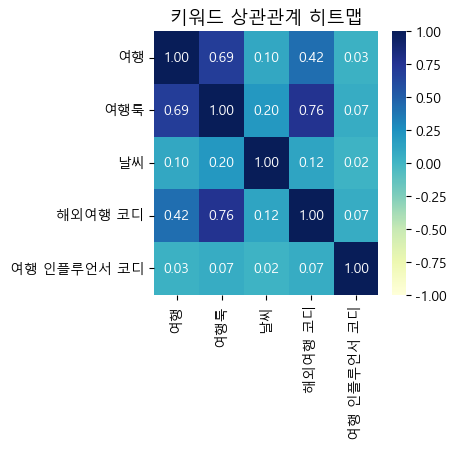

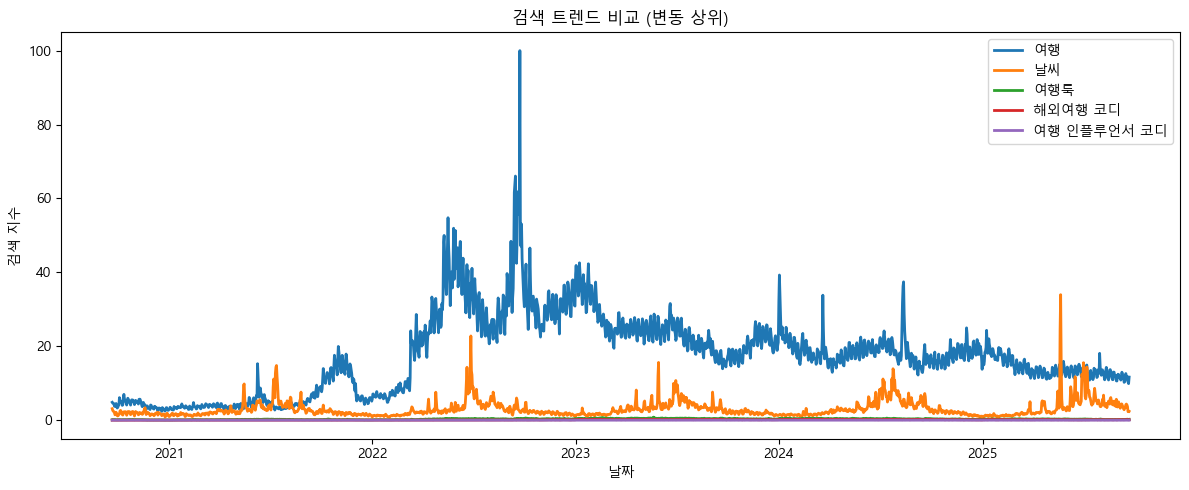

In [26]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# -------------------------------
# 0) 한글 폰트(환경별 자동 설정)
# -------------------------------
if platform.system() == "Windows":
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == "Darwin":
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# -------------------------------
# 1) 파일/시트 설정
# -------------------------------
file_path = "datalab (1).xlsx"  # ← 로컬 파일명으로 변경
sheet_name = "개요"                                       # 없으면 첫 시트 사용 권장

# -------------------------------
# 2) 네이버 데이터랩 wide → tidy 변환
#    (헤더 자동 탐지, 날짜/값 페어 자동 추출)
# -------------------------------
raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

# 헤더 후보 행(위쪽 15행에서) 중,
# 짝수 인덱스 컬럼(0,2,4,…)에 '날짜' 문자열이 2개 이상 있는 첫 행을 헤더로 가정
header_row = None
max_scan = min(15, len(raw))
for r in range(max_scan):
    row_vals = raw.iloc[r, :].astype(str).str.strip().tolist()
    even_cols = row_vals[0::2]  # 0,2,4,…
    if sum(v == "날짜" for v in even_cols if v is not None) >= 2:
        header_row = r
        break
if header_row is None:
    # 차선책: 가장 위 행을 헤더로 두되, '날짜'가 있는 패턴만 선택
    header_row = 5  # 데이터랩 기본 케이스
    # 필요시 위 숫자만 조정해도 동작

# 헤더 행에서 각 '값' 컬럼의 라벨(키워드명) 추출
row_vals = raw.iloc[header_row, :].tolist()
ncols = len(row_vals)

pairs = []  # (date_col_idx, value_col_idx, label)
for j in range(1, ncols, 2):  # 1,3,5,…
    label = str(row_vals[j]).strip() if pd.notna(row_vals[j]) else f"키워드{(j+1)//2}"
    # 값 열이 전부 NaN이면 스킵
    col_vals = raw.iloc[header_row+1:, j]
    if pd.isna(col_vals).all():
        continue
    pairs.append((j-1, j, label))

# 각 페어를 개별 시리즈로 정리 후 병합
series_list = []
for (dcol, vcol, label) in pairs:
    tmp = raw.iloc[header_row+1:, [dcol, vcol]].copy()
    tmp.columns = ["날짜", label]
    tmp["날짜"] = pd.to_datetime(tmp["날짜"], errors="coerce")
    tmp[label] = pd.to_numeric(tmp[label], errors="coerce")
    tmp = tmp.dropna(subset=["날짜"]).dropna(subset=[label], how="all")
    series_list.append(tmp)

# 공통 날짜 기준으로 순차 병합
from functools import reduce
df = reduce(lambda L, R: pd.merge(L, R, on="날짜", how="outer"), series_list)
df = df.sort_values("날짜").reset_index(drop=True)

# 숫자 컬럼만 추려 상관계수 계산 대상 선정
value_cols = [c for c in df.columns if c != "날짜"]
# 완전 결측/상수(분산 0) 컬럼 제거
clean_cols = []
for c in value_cols:
    vc = df[c].dropna()
    if len(vc) >= 3 and vc.std(ddof=1) > 0:
        clean_cols.append(c)

if not clean_cols:
    raise ValueError("상관계수 계산에 사용할 유효 컬럼이 없습니다. (결측/상수열)")

df_clean = df[["날짜"] + clean_cols].dropna(how="all")
corr = df_clean[clean_cols].corr(method="pearson")

print("상관계수 표 (피어슨):")
print(corr)

# -------------------------------
# 3) 히트맵
# -------------------------------
plt.figure(figsize=(1.6 + 0.6*len(clean_cols), 1.6 + 0.6*len(clean_cols)))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", vmin=-1, vmax=1)
plt.title("키워드 상관관계 히트맵", fontsize=13)
plt.tight_layout()
plt.show()

# -------------------------------
# 4) 시계열 라인차트 (상위 변동 4~6개 자동 선택)
# -------------------------------
# 변동성이 큰 순으로 상위 N개 선택
N = min(6, len(clean_cols))
top_cols = (df_clean[clean_cols].std().sort_values(ascending=False).head(N)).index.tolist()

plt.figure(figsize=(12, 5))
for c in top_cols:
    plt.plot(df_clean["날짜"], df_clean[c], label=c, linewidth=2)
plt.legend()
plt.xlabel("날짜"); plt.ylabel("검색 지수")
plt.title("검색 트렌드 비교 (변동 상위)")
plt.tight_layout()
plt.show()


상관계수 표 (피어슨):
           여행       여행룩
여행   1.000000  0.218293
여행룩  0.218293  1.000000


C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\user\AppData\Local\Temp\ipykernel_16064\4045999979.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  "날짜": pd.to_datetime(df_raw[date_col], errors="coerce"),
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 47337 (\N{HANGUL SYLLABLE RUG}) missing from

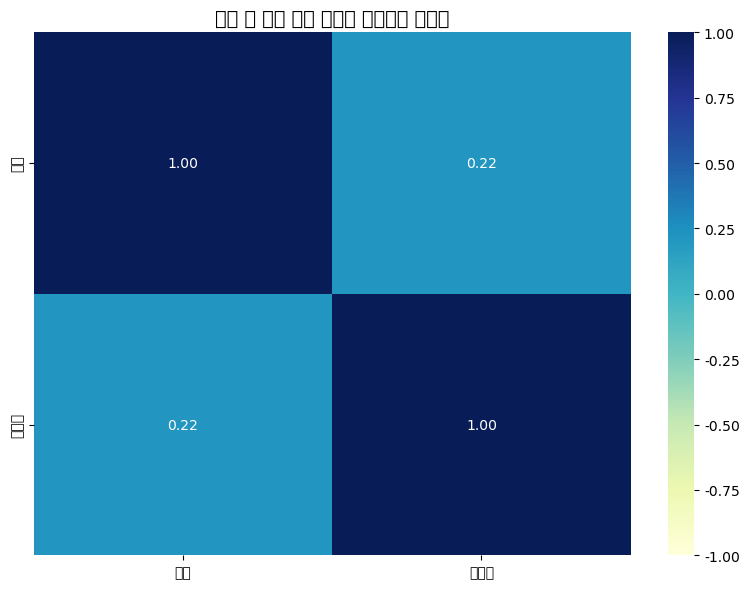

C:\Users\user\AppData\Local\Temp\ipykernel_16064\4045999979.py:78: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16064\4045999979.py:78: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16064\4045999979.py:78: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16064\4045999979.py:78: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16064\4045999979.py:78: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_16064\4045999979.py:78: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font

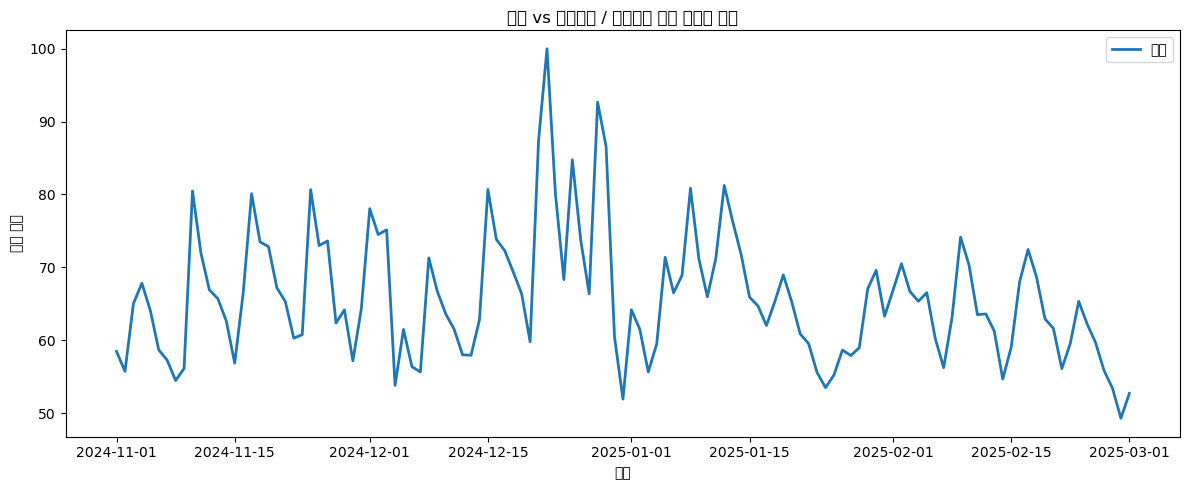

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.font_manager as fm
import os

# ================== 설정 ==================
file_path = "datalab (4).xlsx"   # 엑셀 파일 경로
sheet_name = "개요"               # 시트 이름
header_row = 5                   # 헤더가 있는 행(0-index 기준)

# NanumGothic 있으면 적용 (없어도 무시)
try:
    fonts = [f.name for f in fm.fontManager.ttflist]
    if "NanumGothic" in fonts:
        matplotlib.rcParams["font.family"] = "NanumGothic"
except Exception:
    pass
matplotlib.rcParams["axes.unicode_minus"] = False

# ================== 1) 데이터 불러오기 ==================
if not os.path.exists(file_path):
    raise FileNotFoundError(f"엑셀 파일이 없습니다: {file_path}")

df_raw = pd.read_excel(file_path, sheet_name=sheet_name, header=header_row)

# 날짜 컬럼 추론: '기간' 우선, 없으면 '연령대' 사용, 그것도 없으면 첫 컬럼
date_col = None
if "기간" in df_raw.columns:
    date_col = "기간"
elif "연령대" in df_raw.columns:
    date_col = "연령대"
else:
    date_col = df_raw.columns[0]

# 목표 컬럼: 예시 코드와 동일한 레이아웃 가정
# (네 파일이 이와 다르면 아래 맵핑만 바꿔주면 됨)
col_map = {
    "여행": "전체",
    "여행룩": "Unnamed: 3",
    "공항패션": "Unnamed: 5",
    "리조트룩": "Unnamed: 7",
    "여행코디": "Unnamed: 9"
}
# 실제 존재하는 컬럼만 사용
valid_map = {k: v for k, v in col_map.items() if v in df_raw.columns}

# ================== 2) 전처리 ==================
df = pd.DataFrame({
    "날짜": pd.to_datetime(df_raw[date_col], errors="coerce"),
    **{k: pd.to_numeric(df_raw[v], errors="coerce") for k, v in valid_map.items()}
})
df = df.dropna().sort_values("날짜")

# ================== 3) 상관계수 계산 ==================
corr = df.drop(columns=["날짜"]).corr(method="pearson")
print("상관계수 표 (피어슨):")
print(corr)

# ================== 4) 상관계수 히트맵 ==================
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", vmin=-1, vmax=1)
plt.title("여행 및 패션 관련 키워드 상관관계 히트맵", fontsize=14)
plt.tight_layout()
plt.show()

# ================== 5) 시계열 그래프 ==================
# 예: 여행 vs 리조트룩/여행코디 (있을 때만 그리기)
plt.figure(figsize=(12, 5))
plt.plot(df["날짜"], df["여행"], label="여행", linewidth=2) if "여행" in df.columns else None
plt.plot(df["날짜"], df["리조트룩"], label="리조트룩", linewidth=2) if "리조트룩" in df.columns else None
plt.plot(df["날짜"], df["여행코디"], label="여행코디", linewidth=2) if "여행코디" in df.columns else None
plt.legend()
plt.xlabel("날짜")
plt.ylabel("검색 지수")
plt.title("여행 vs 리조트룩 / 여행코디 검색 트렌드 비교")
plt.tight_layout()
plt.show()
